## 1. Carga de datos y filtrado 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
rng = np.random.default_rng(42)

In [2]:
datos = pd.read_csv("DatosUsados/LC_loans_granting_model_dataset.csv", low_memory=False)
datos['issue_d'] = pd.to_datetime(datos['issue_d'], format='%b-%Y')

datos_filtrados = datos[(datos['issue_d'].dt.year >= 2016) & (datos['issue_d'].dt.year <= 2018)].copy()
print(f"Préstamos totales(2007-2018): {len(datos):,}")
print(f"Préstamos tras filtrar 2016-2018: {len(datos_filtrados):,}")

Préstamos totales(2007-2018): 1,347,681
Préstamos tras filtrar 2016-2018: 518,334


In [3]:
datos_filtrados.to_csv("DatosUsados/lc_loans_2016_2018.csv", index=False)

## 2. Dataset de trabajo


In [4]:
datos_filtrados = pd.read_csv("DatosUsados/lc_loans_2016_2018.csv", low_memory=False)
datos_filtrados['issue_d'] = pd.to_datetime(datos_filtrados['issue_d'])
datos_eda = datos_filtrados.copy()

print(f"filtrado: {datos_filtrados.shape[0]:,} filas, {datos_filtrados.shape[1]} columnas")
datos_filtrados.info()

filtrado: 518,334 filas, 15 columnas
<class 'pandas.DataFrame'>
RangeIndex: 518334 entries, 0 to 518333
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                518334 non-null  int64         
 1   issue_d           518334 non-null  datetime64[us]
 2   revenue           518334 non-null  float64       
 3   dti_n             518334 non-null  float64       
 4   loan_amnt         518334 non-null  int64         
 5   fico_n            518334 non-null  float64       
 6   experience_c      518334 non-null  int64         
 7   emp_length        518334 non-null  str           
 8   purpose           518334 non-null  str           
 9   home_ownership_n  518334 non-null  str           
 10  addr_state        518334 non-null  str           
 11  zip_code          518333 non-null  str           
 12  Default           518334 non-null  int64         
 13  title             501816 non-null

## 3. Datos nulos y duplicados

In [5]:
nulos = datos_eda.isnull().sum()
nulos_pct = (nulos / len(datos_eda) * 100).round(3)
pd.DataFrame({'nulos': nulos, '% nulos': nulos_pct}).query('nulos > 0').sort_values('nulos', ascending=False)

,nulos,% nulos
desc,518323,99.998
title,16518,3.187
zip_code,1,0.000


In [6]:
print(f"Filas duplicadas {datos_eda.duplicated().sum()}")
print(f"Identificadores duplicados: {datos_eda['id'].duplicated().sum()}")

Filas duplicadas 0
Identificadores duplicados: 0


## 4. Variable objetivo 

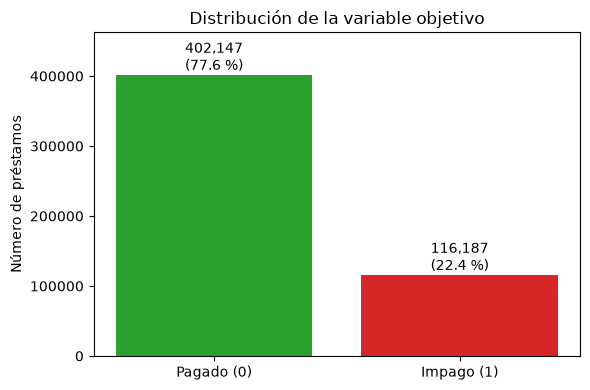

In [7]:
vc = datos_eda['Default'].value_counts().reindex([0, 1])
pct = vc /len(datos_eda) *100

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(['Pagado (0)', 'Impago (1)'], vc.values, color=['tab:green', 'tab:red'])
for barra, clase in zip(barras, [0, 1]):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
            f"{vc.loc[clase]:,}\n({pct.loc[clase]:.1f} %)", ha='center', va='bottom')
ax.set_title('Distribución de la variable objetivo')
ax.set_ylabel('Número de préstamos')
ax.set_ylim(0, vc.max() * 1.15)
plt.tight_layout()
plt.show()


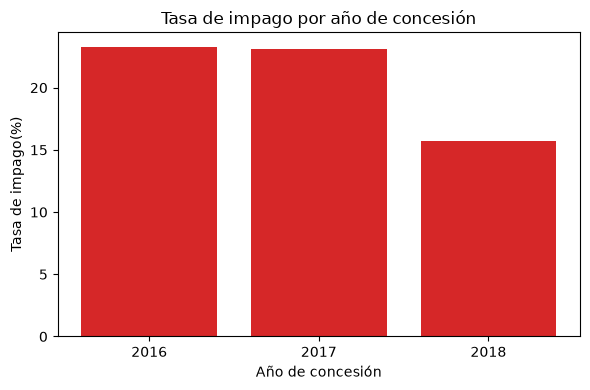

,mean,count
issue_d,,
2016,0.2328,293057
2017,0.2313,169117
2018,0.1575,56160


In [8]:
tasa_anual = datos_eda.groupby(datos_eda['issue_d'].dt.year)['Default'].agg(['mean', 'count'])
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tasa_anual.index.astype(str), tasa_anual['mean'] * 100, color='tab:red')
ax.set_title('Tasa de impago por año de concesión')
ax.set_xlabel('Año de concesión')
ax.set_ylabel('Tasa de impago(%)')
plt.tight_layout()
plt.show()
tasa_anual.round(4)

## 5. Análisis de variables cuantitativas

### 5.1. Univariante


In [9]:
numericas = ['revenue', 'dti_n', 'loan_amnt', 'fico_n']
nombres_numericas = {'revenue': 'Ingresos anuales','dti_n': 'Ratio deuda-ingresos','loan_amnt': 'Importe solicitado','fico_n': 'Puntuación FICO',}
datos_eda['dti_n'] = datos_eda['dti_n'].replace(999, np.nan) # Provisional. Para esta sección de análisis

tabla_numericas = datos_eda[numericas].describe().T
tabla_numericas['asimetría'] = datos_eda[numericas].skew()
tabla_numericas['curtosis'] = datos_eda[numericas].kurtosis()
tabla_numericas['rango'] = tabla_numericas['max'] - tabla_numericas['min']
tabla_numericas.round(2)

,count,mean,std,min,25%,50%,75%,max,asimetría,curtosis,rango
revenue,518334.0,81880.63,78352.89,2000.0,50000.0,70000.0,98650.00,10999200.00,44.45,4203.42,10997200.00
dti_n,518297.0,18.77,11.92,0.0,11.9,17.9,24.63,991.57,16.35,833.77,991.57
loan_amnt,518334.0,14455.89,9225.64,1000.0,7200.0,12000.0,20000.00,40000.00,0.83,-0.05,39000.00
fico_n,518334.0,700.04,33.58,662.0,672.0,692.0,717.00,847.50,1.24,1.38,185.50


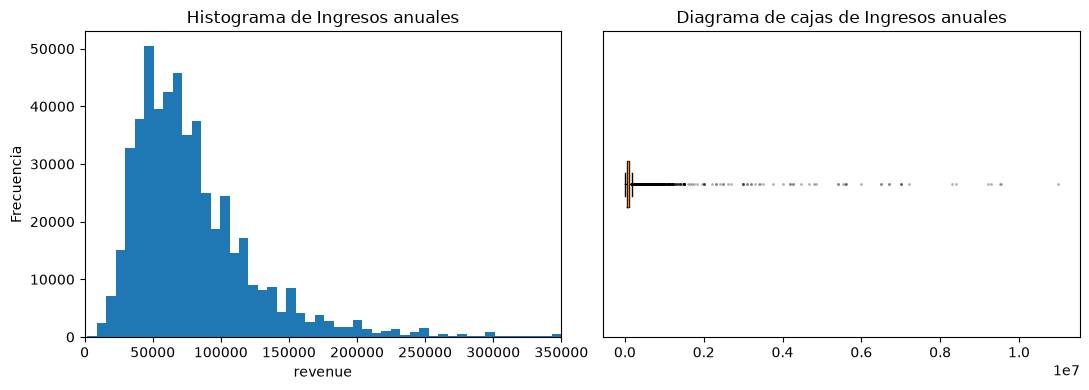

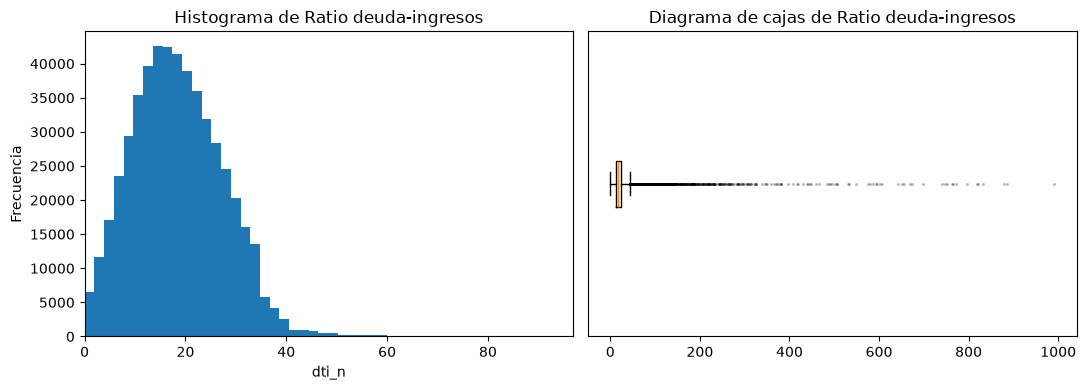

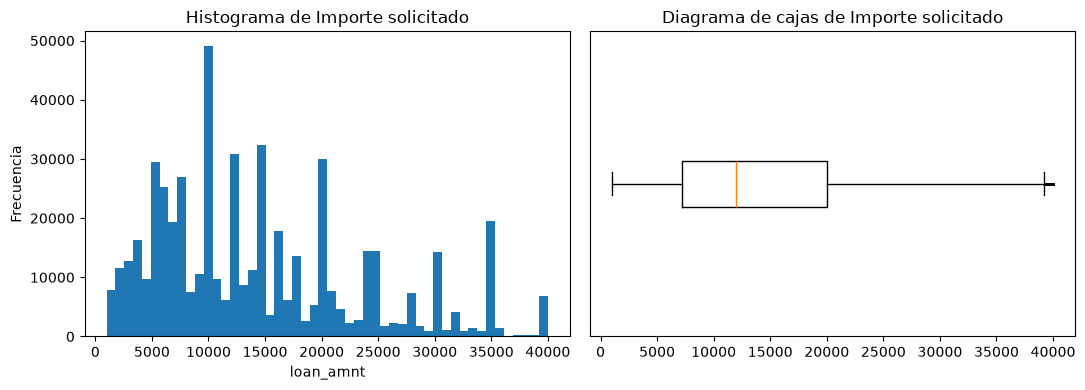

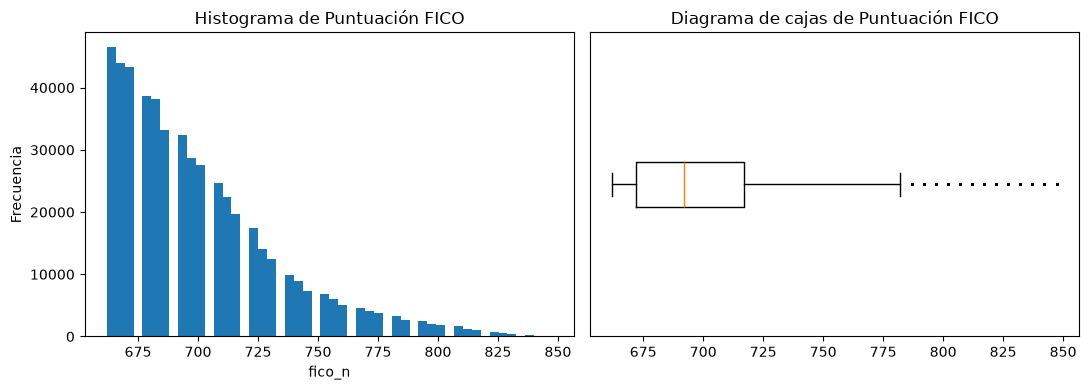

In [10]:
percentiles_visuales = {'revenue': 0.995, 'dti_n': 0.999}  #percentil usado histograma

for variable in numericas:
    serie = datos_eda[variable].dropna()
    limite = serie.quantile(percentiles_visuales[variable]) if variable in percentiles_visuales else serie.max()
    serie_hist = serie[serie <= limite]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(serie_hist, bins=50, color='tab:blue')
    axes[0].set_title(f'Histograma de {nombres_numericas[variable]}')
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel('Frecuencia')
    axes[1].boxplot(serie, orientation='horizontal',
                     flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
    axes[1].set_title(f'Diagrama de cajas de {nombres_numericas[variable]}')
    axes[1].set_yticks([])

    if variable in percentiles_visuales:
        axes[0].set_xlim(0, limite)
    plt.tight_layout()
    plt.show()

### 5.2. Bivariante: 

In [11]:
tabla_bivariante = (datos_eda.groupby('Default')[numericas].agg(['mean', 'median']).T.reset_index().rename(columns={'level_0': 'variable', 'level_1': 'estadístico', 0: 'Pagado (0)', 1: 'Impago (1)'}))
tabla_bivariante['estadístico'] = tabla_bivariante['estadístico'].replace({'mean': 'media', 'median': 'mediana'})
tabla_bivariante.round(2)

Default,variable,estadístico,Pagado (0),Impago (1)
0,revenue,media,83699.83,75584.00
1,revenue,mediana,70000.00,65000.00
2,dti_n,media,18.24,20.62
3,dti_n,mediana,17.31,20.07
4,loan_amnt,media,14107.49,15661.78
5,loan_amnt,mediana,12000.00,14000.00
6,fico_n,media,702.65,691.02
7,fico_n,mediana,692.00,682.00


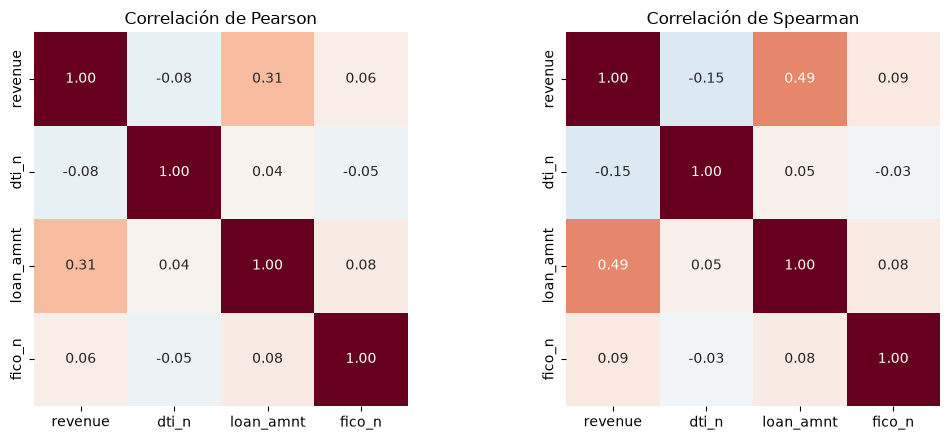

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metodo, nombre in zip(axes, ['pearson', 'spearman'], ['Pearson', 'Spearman']):
    correlaciones = datos_eda[numericas].corr(method=metodo)
    sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(f'Correlación de {nombre}')
plt.tight_layout()
plt.show()

## 6. Depuración de datos

### 6.1. Valores atípicos en revenue

In [13]:
media, std = datos_eda['revenue'].mean(), datos_eda['revenue'].std()
outliers_std = (datos_eda['revenue'] > media + 3*std) | (datos_eda['revenue'] < media - 3*std)
mediana = datos_eda['revenue'].median()
mad = (datos_eda['revenue'] - mediana).abs().median()
outliers_mad = (datos_eda['revenue'] > mediana + 8*mad) | (datos_eda['revenue'] < mediana - 8*mad)
q1, q3 = datos_eda['revenue'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers_iqr = (datos_eda['revenue'] > q3 + 3*iqr) | (datos_eda['revenue'] < q1 - 3*iqr)
outliers_revenue = (outliers_std.astype(int) + outliers_mad.astype(int) + outliers_iqr.astype(int)) >= 2

print(f"Desviación típica: {outliers_std.sum()} | MAD: {outliers_mad.sum()} | IQR: {outliers_iqr.sum()}")
print(f"Atípicos finales (≥2 métodos de acuerdo): {outliers_revenue.sum()} ({outliers_revenue.mean()*100:.3f} %)")
print(f"Tasa de impago en atípicos: {datos_eda.loc[outliers_revenue, 'Default'].mean():.3f}")
print(f"Tasa de impago en el resto:  {datos_eda.loc[~outliers_revenue, 'Default'].mean():.3f}")

Desviación típica: 3524 | MAD: 6468 | IQR: 8328
Atípicos finales (≥2 métodos de acuerdo): 6468 (1.248 %)
Tasa de impago en atípicos: 0.141
Tasa de impago en el resto:  0.225


### 6.2. Valores ausentes


In [14]:
sin_title = datos_eda['title'].isna()
print(f"Tasa de impago SIN título: {datos_eda.loc[sin_title, 'Default'].mean():.4f}  (n={sin_title.sum()})")
print(f"Tasa de impago CON título: {datos_eda.loc[~sin_title, 'Default'].mean():.4f}")

Tasa de impago SIN título: 0.2911  (n=16518)
Tasa de impago CON título: 0.2220


In [15]:
datos_eda = datos_eda.drop(columns=['desc'])
datos_eda['sin_titulo'] = datos_eda['title'].isna().astype(int)
datos_eda['title'] = datos_eda['title'].fillna('Sin especificar')
datos_eda['zip_code'] = datos_eda['zip_code'].fillna('Desconocido')
mediana_dti_eda = datos_eda['dti_n'].median()
datos_eda['dti_n'] = datos_eda['dti_n'].fillna(mediana_dti_eda)
print(f"Mediana de dti_n imputada en esta copia: {mediana_dti_eda:.2f}")
print(f"Nulos restantes: {datos_eda.isnull().sum().sum()}")

Mediana de dti_n imputada en esta copia: 17.90
Nulos restantes: 0


## 7. Variables categóricas

### 7.1. Cardinalidad 

In [16]:
datos_eda.nunique().sort_values().to_frame('modalidades')

,modalidades
experience_c,1
sin_titulo,2
Default,2
home_ownership_n,4
emp_length,12
purpose,13
title,14
issue_d,36
fico_n,38
addr_state,50


In [17]:
datos_eda = datos_eda.drop(columns=['experience_c'])

### 7.2. Distribución univariante

In [18]:
orden_emp = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
             '6 years', '7 years', '8 years', '9 years', '10+ years', 'NI']
categoricas = ['home_ownership_n', 'emp_length', 'purpose', 'addr_state']
nombres_categoricas = {
    'home_ownership_n': 'Situación de la vivienda',
    'emp_length': 'Antigüedad laboral',
    'purpose': 'Finalidad del préstamo',
    'addr_state': 'Estado de residencia',
}

def tabla_frecuencias(serie, orden=None):
    tabla = serie.value_counts(dropna=False).rename_axis('categoría').reset_index(name='n')
    tabla['categoría'] = tabla['categoría'].astype(str)
    if orden is not None:
        posicion = {v: i for i, v in enumerate(orden)}
        tabla = tabla.sort_values('categoría', key=lambda s: s.map(posicion)).reset_index(drop=True)
    tabla['%'] = (tabla['n'] / len(serie) * 100).round(2)
    return tabla

tablas_frecuencia = {
    var: tabla_frecuencias(datos_eda[var], orden_emp if var == 'emp_length' else None)
    for var in categoricas
}

resumen_categoricas = pd.DataFrame([
    {
        'variable': nombres_categoricas[var],
        'modalidades': datos_eda[var].nunique(),
        'moda': (t := tablas_frecuencia[var]).loc[t['n'].idxmax(), 'categoría'],
        '% de la moda': t.loc[t['n'].idxmax(), '%'],
        'modalidades < 1 %': int((t['%'] < 1).sum()),
    }
    for var in categoricas
])
resumen_categoricas

,variable,modalidades,moda,% de la moda,modalidades < 1 %
0,Situación de la vivienda,4,MORTGAGE,49.37,1
1,Antigüedad laboral,12,10+ years,33.51,0
2,Finalidad del préstamo,13,debt_consolidation,56.50,5
3,Estado de residencia,50,CA,14.16,22


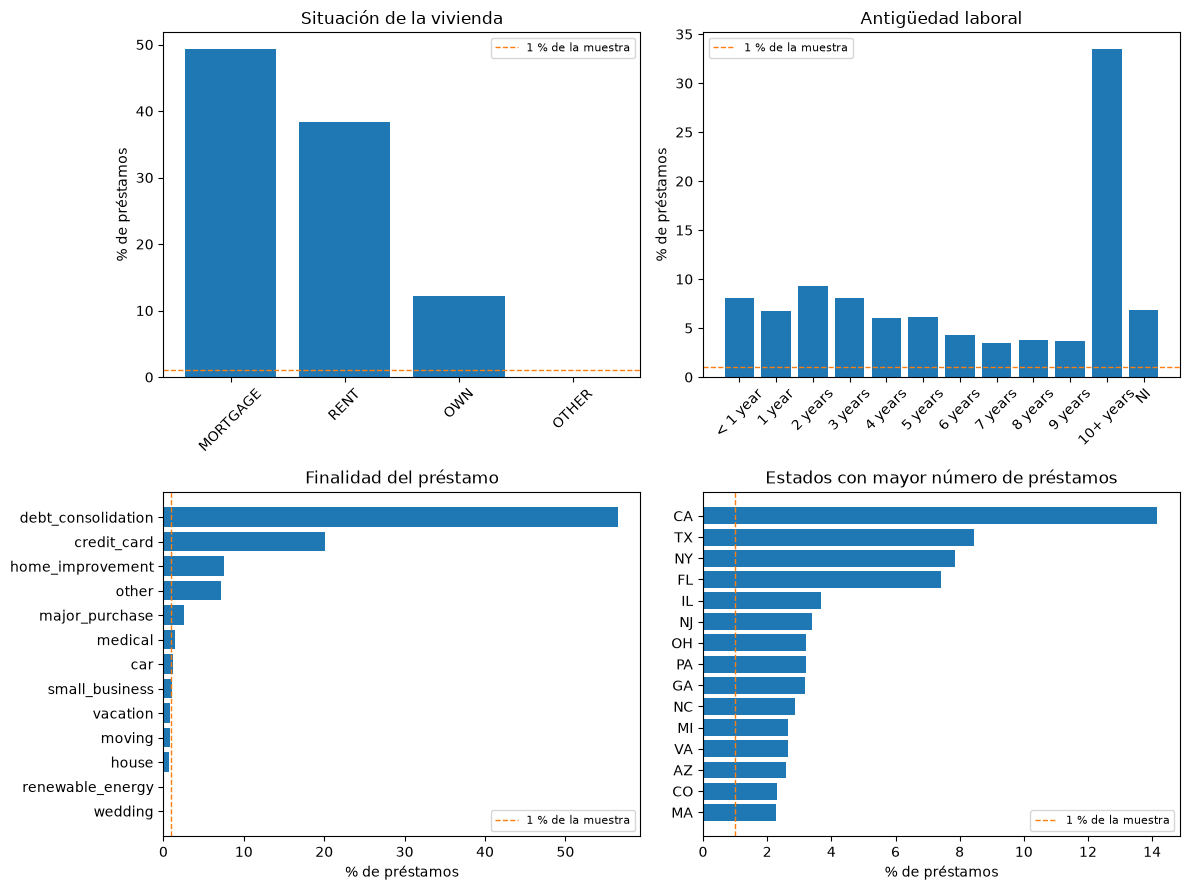

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, var in zip(axes.flat, categoricas):
    tabla = tablas_frecuencia[var].copy()
    if var == 'addr_state':
        tabla = tabla.nlargest(15, 'n').sort_values('%')
        titulo = 'Estados con mayor número de préstamos'
    else:
        titulo = nombres_categoricas[var]
        if var == 'purpose':
            tabla = tabla.sort_values('%')

    if var in ('purpose', 'addr_state'):
        ax.barh(tabla['categoría'], tabla['%'], color='tab:blue')
        ax.axvline(1, color='tab:orange', linestyle='--', linewidth=1, label='1 % de la muestra')
        ax.set_xlabel('% de préstamos')
    else:
        ax.bar(tabla['categoría'], tabla['%'], color='tab:blue')
        ax.axhline(1, color='tab:orange', linestyle='--', linewidth=1, label='1 % de la muestra')
        ax.set_ylabel('% de préstamos')
        ax.tick_params(axis='x', rotation=45)

    ax.set_title(titulo)
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

### 7.3. Bivariante: V de Cramer 



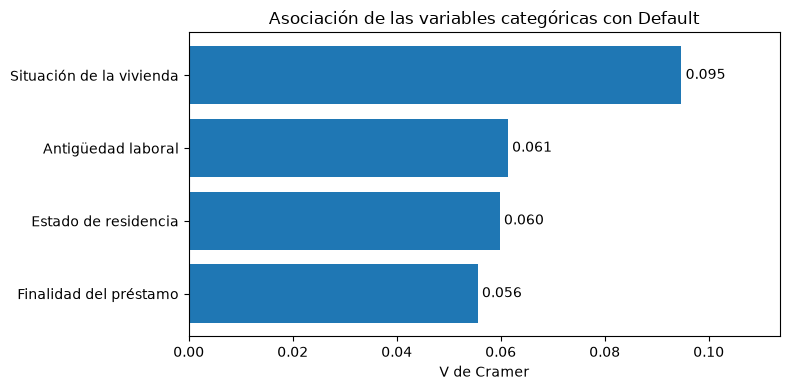

In [20]:
def v_cramer(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

cramer_default = pd.Series(
    {nombres_categoricas[var]: v_cramer(datos_eda[var], datos_eda['Default']) for var in categoricas},
    name='V de Cramer',
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(cramer_default.index, cramer_default.values, color='tab:blue')
ax.bar_label(barras, fmt='%.3f', padding=3)
ax.set_title('Asociación de las variables categóricas con Default')
ax.set_xlabel('V de Cramer')
ax.set_xlim(0, cramer_default.max() * 1.2)
plt.tight_layout()
plt.show()

In [21]:
# Redundancia entre title y purpose.
v_title_purpose = v_cramer(datos_eda['title'], datos_eda['purpose'])
print(f"V de Cramer entre title y purpose: {v_title_purpose:.3f}")

V de Cramer entre title y purpose: 0.945


## 8. Estabilidad temporal (PSI)



In [22]:
datos_eda['year'] = datos_eda['issue_d'].dt.year
ref_2016 = datos_eda.loc[datos_eda['year'] == 2016]
act_2018 = datos_eda.loc[datos_eda['year'] == 2018]

def psi_desde_conteos(esperada, actual, epsilon=1e-6):
    esperada = (esperada / esperada.sum()).clip(lower=epsilon)
    actual = (actual / actual.sum()).clip(lower=epsilon)
    categorias = esperada.index.union(actual.index)
    esperada = esperada.reindex(categorias, fill_value=epsilon)
    actual = actual.reindex(categorias, fill_value=epsilon)
    return float(((actual - esperada) * np.log(actual / esperada)).sum())

def psi_numerica(variable, n_tramos=10):
    cortes = np.unique(ref_2016[variable].dropna().quantile(np.linspace(0, 1, n_tramos + 1)))
    cortes = np.r_[-np.inf, cortes[1:-1], np.inf]
    esperada = pd.cut(ref_2016[variable], cortes).astype('string').fillna('PERDIDO').value_counts()
    actual = pd.cut(act_2018[variable], cortes).astype('string').fillna('PERDIDO').value_counts()
    return psi_desde_conteos(esperada, actual)

def psi_categorica(variable):
    esperada = ref_2016[variable].astype('string').fillna('PERDIDO').value_counts()
    actual = act_2018[variable].astype('string').fillna('PERDIDO').value_counts()
    return psi_desde_conteos(esperada, actual)

psi = {var: psi_numerica(var) for var in numericas}
for var in ['home_ownership_n', 'emp_length', 'purpose', 'addr_state', 'sin_titulo']:
    psi[var] = psi_categorica(var)

tabla_psi = pd.Series(psi, name='PSI').sort_values(ascending=False).to_frame()
tabla_psi['nivel'] = np.select(
    [tabla_psi['PSI'] < 0.10, tabla_psi['PSI'] < 0.25], ['Bajo', 'Moderado'], default='Elevado'
)
tabla_psi.round(3)

,PSI,nivel
sin_titulo,0.620,Elevado
fico_n,0.142,Moderado
purpose,0.044,Bajo
loan_amnt,0.037,Bajo
dti_n,0.034,Bajo
revenue,0.029,Bajo
emp_length,0.015,Bajo
addr_state,0.011,Bajo
home_ownership_n,0.005,Bajo


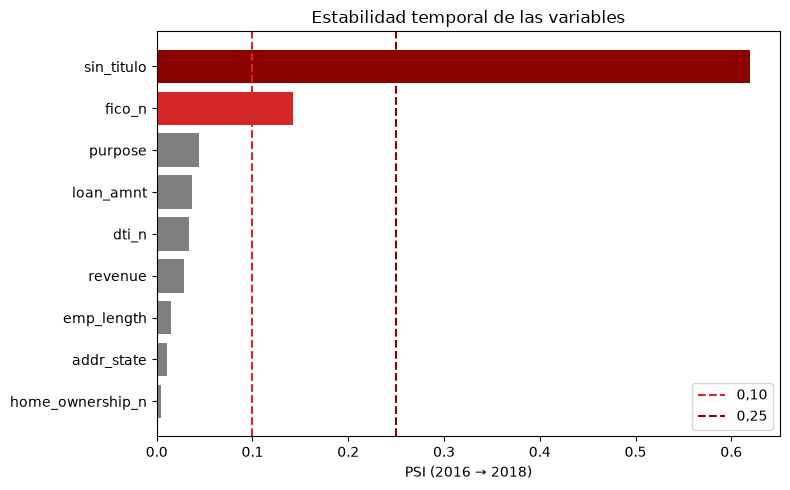

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
orden = tabla_psi.sort_values('PSI')
colores = ['tab:gray' if v < 0.10 else 'tab:red' if v < 0.25 else 'darkred' for v in orden['PSI']]
ax.barh(orden.index, orden['PSI'], color=colores)
ax.axvline(0.10, color='tab:red', linestyle='--', label='0,10')
ax.axvline(0.25, color='darkred', linestyle='--', label='0,25')
ax.set_xlabel('PSI (2016 → 2018)')
ax.set_title('Estabilidad temporal de las variables')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. PCA


In [24]:

variables_cluster = ['revenue', 'dti_n', 'loan_amnt', 'fico_n']
nombres_transformadas = ['log_revenue', 'log_dti_n', 'loan_amnt', 'fico_n']

X = datos_eda[variables_cluster].copy()
X['revenue'] = np.log1p(X['revenue'])
X['dti_n'] = np.log1p(X['dti_n'])

scaler = StandardScaler()
X_esc = scaler.fit_transform(X)
pca = PCA().fit(X_esc)
X_pca = pca.transform(X_esc)

varianza = pd.DataFrame({
    'varianza explicada (%)': pca.explained_variance_ratio_ * 100,
    'varianza acumulada (%)': pca.explained_variance_ratio_.cumsum() * 100,
}, index=[f'PC{i+1}' for i in range(4)])

cargas = pd.DataFrame(pca.components_, columns=nombres_transformadas, index=varianza.index)
varianza.round(2)

,varianza explicada (%),varianza acumulada (%)
PC1,38.70,38.70
PC2,26.76,65.46
PC3,22.97,88.43
PC4,11.57,100.00


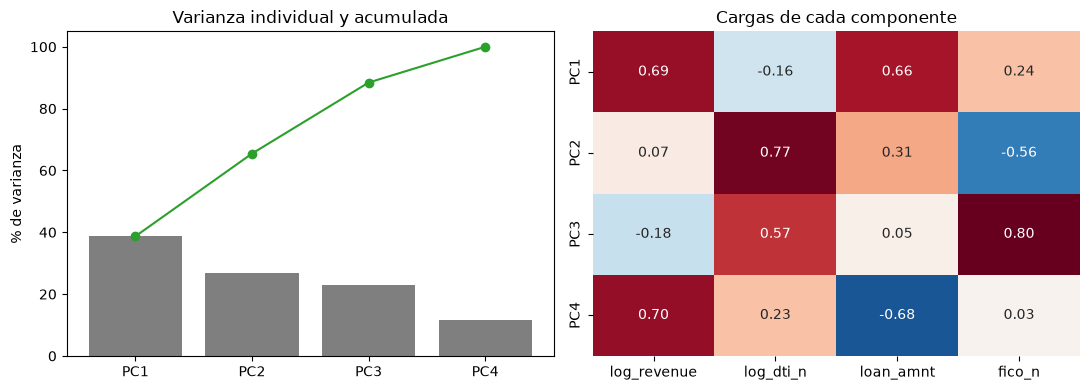

,log_revenue,log_dti_n,loan_amnt,fico_n
PC1,0.692,-0.162,0.663,0.235
PC2,0.070,0.768,0.311,-0.555
PC3,-0.180,0.574,0.045,0.797
PC4,0.696,0.232,-0.679,0.029


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(varianza.index, varianza['varianza explicada (%)'], color='tab:gray')
axes[0].plot(varianza.index, varianza['varianza acumulada (%)'], marker='o', color='tab:green')
axes[0].set_ylabel('% de varianza')
axes[0].set_ylim(0, 105)
axes[0].set_title('Varianza individual y acumulada')
sns.heatmap(cargas, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar=False, ax=axes[1])
axes[1].set_title('Cargas de cada componente')
plt.tight_layout()
plt.show()
cargas.round(3)

## 11. Clustering 
### 11.1. Selección número de clusters

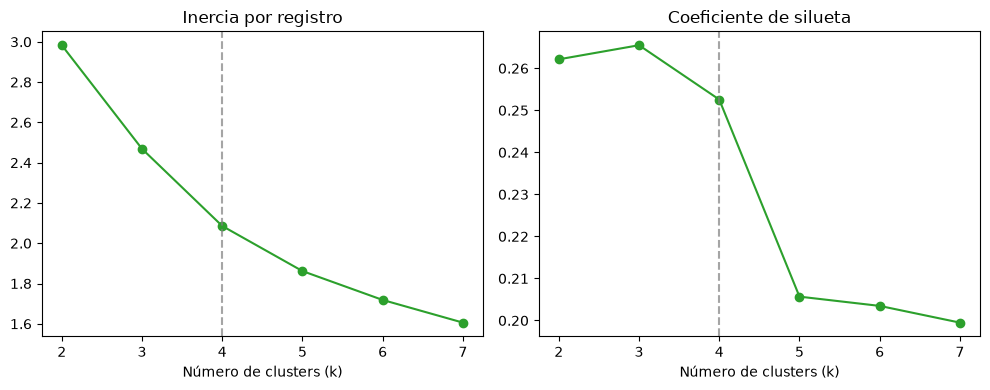

,inercia,silueta
k,,
2,2.9832,0.2621
3,2.4686,0.2655
4,2.0856,0.2526
5,1.8617,0.2057
6,1.7183,0.2035
7,1.6058,0.1995


In [26]:


ks = range(2, 8)
muestra = rng.choice(len(X_esc), 40000, replace=False)
X_muestra = X_esc[muestra]

diagnostico_k = pd.DataFrame([
    {
        'k': k,
        'inercia': (m := KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_muestra)).inertia_ / len(X_muestra),
        'silueta': silhouette_score(X_muestra, m.labels_),
    }
    for k in ks
]).set_index('k')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(diagnostico_k.index, diagnostico_k['inercia'], marker='o', color='tab:green')
axes[0].set_title('Inercia por registro')
axes[1].plot(diagnostico_k.index, diagnostico_k['silueta'], marker='o', color='tab:green')
axes[1].set_title('Coeficiente de silueta')
for ax in axes:
    ax.set_xlabel('Número de clusters (k)')
    ax.axvline(4, color='tab:gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

diagnostico_k.round(4)

In [27]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20).fit(X_esc)
datos_eda['cluster'] = kmeans.labels_
perfil = datos_eda.groupby('cluster')[numericas].median().round(1)
perfil['n'] = datos_eda['cluster'].value_counts().sort_index()
perfil['%'] = (perfil['n'] / len(datos_eda) * 100).round(1)
perfil['tasa_impago'] = (datos_eda.groupby('cluster')['Default'].mean() * 100).round(1)
perfil

,revenue,dti_n,loan_amnt,fico_n,n,%,tasa_impago
cluster,,,,,,,
0,75000.0,8.1,10000.0,682.0,94406,18.2,17.7
1,52000.0,22.0,9900.0,682.0,222527,42.9,26.5
2,108000.0,18.7,25000.0,692.0,128414,24.8,25.4
3,70000.0,16.2,12000.0,757.0,72987,14.1,10.9


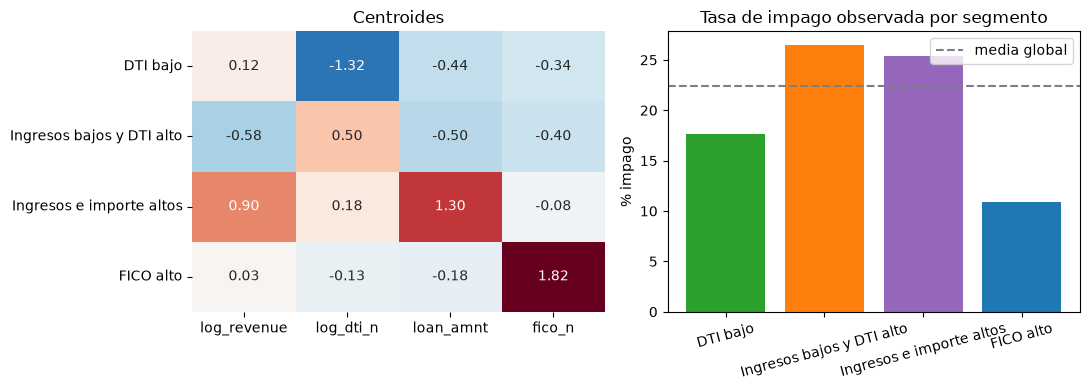

In [28]:
nombres_clusters = {0: 'DTI bajo',1: 'Ingresos bajos y DTI alto',2: 'Ingresos e importe altos',3: 'FICO alto',}
colores_cluster = ['tab:green', 'tab:orange', 'tab:purple', 'tab:blue']

centroides_z = pd.DataFrame(
    kmeans.cluster_centers_, columns=nombres_transformadas,
    index=[nombres_clusters[i] for i in range(k_final)],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(centroides_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar=False, ax=axes[0])
axes[0].set_title('Centroides')

tasas = datos_eda.groupby('cluster')['Default'].mean() * 100
axes[1].bar([nombres_clusters[i] for i in tasas.index], tasas.values, color=colores_cluster)
axes[1].axhline(datos_eda['Default'].mean() * 100, color='tab:gray', linestyle='--', label='media global')
axes[1].set_ylabel('% impago')
axes[1].set_title('Tasa de impago observada por segmento')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
plt.tight_layout()
plt.show()

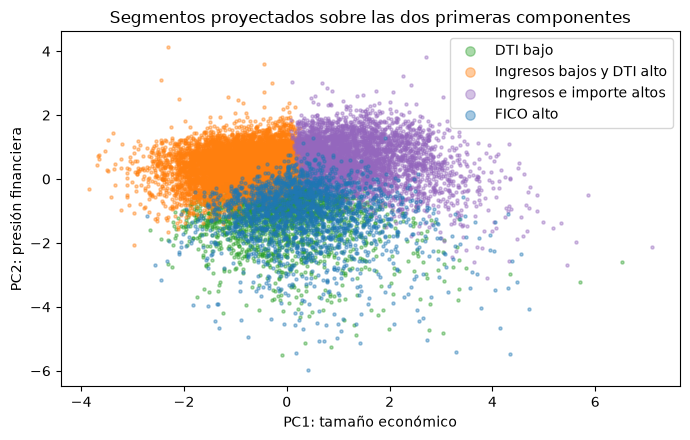

In [29]:

muestra_plot = rng.choice(len(X_pca), 15000, replace=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
for c in range(k_final):
    m = datos_eda['cluster'].values[muestra_plot] == c
    ax.scatter(X_pca[muestra_plot][m, 0], X_pca[muestra_plot][m, 1],
               s=5, alpha=0.4, color=colores_cluster[c], label=nombres_clusters[c])
ax.set_xlabel('PC1: tamaño económico')
ax.set_ylabel('PC2: presión financiera')
ax.set_title('Segmentos proyectados sobre las dos primeras componentes')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [30]:
import joblib
from pathlib import Path

Path('models').mkdir(exist_ok=True)
joblib.dump({
    'scaler': scaler,
    'pca': pca,
    'kmeans': kmeans,
    'variables': variables_cluster,
    'nombres_clusters': nombres_clusters,
    'perfil': perfil,
    'transformaciones': {'revenue': 'log1p', 'dti_n': 'log1p'},
}, 'models/clustering_perfiles.joblib')

print("Guardado en models/clustering_perfiles.joblib")

Guardado en models/clustering_perfiles.joblib
